# Caso J · 04 Predicción congestión a 15 min — tráfico × meteorología

> _Tutorial · Caso de uso: **J — Tráfico + YOLO** · Capa Medallion: **oro** · Spec: `docs/specs/synthetic-bms/01-product-spec.md`_

Material docente del proyecto **CAPTIA Synthetic Data BMS** — IES Dr. Lluís Simarro,
Curso de Especialización IA & Big Data 2025-2026.


## 1. Objetivo

Predecir `congestion_level(t+15min)` a partir de `vehicle_count(t)`, lluvia y horario. **Predicción real con target lagged**, no clasificación contemporánea. Comparar 3 modelos:

1. Baseline persistencia: `Ĉ(t+15) = C(t)`.
2. RandomForest sobre features tiempo + meteo + cuenta.
3. Modelo solo-meteo (sin `vehicle_count`) — para medir cuánta señal viene del tráfico vs del clima.


## 2. Qué se aprende

- Target lagged (`shift(-1)` en frecuencia 15-min).
- Diagnóstico de leakage por correlación (`corr(X, y) > 0.85` ⇒ auditar el DGP del mock).
- Multi-clase + matriz de confusión + `balanced_accuracy`.
- Comparar modelos con/sin feature crítica para medir contribución.


## 3. Contexto del caso de uso

Operadores de smart city necesitan estimar congestión 15 min antes para ajustar semáforos o avisar a emergencias. La señal entra por dos canales: histórico de cuentas y meteorología. El modelo debe captar **ambos**.


## 4. Relación con CENTINELA+

Tool opcional `predict_congestion(camera_id, horizon_min)` para el chatbot Caso H. Cliente final: ayuntamiento o autopista, no centro educativo.


## 5. Relación con Medallion

Lee plata `traffic_cameras`, escribe oro.


## 6. Datos de entrada

Mock `traffic_camera_mock.csv` con DGP **mixto** (congestion_level depende de hora+lluvia+ruido categórico, no es función directa de vehicle_count).


## 7. Setup y variables de entorno

Cargamos las variables de entorno (`.env`), inicializamos `numpy` con `seed=42` y aplicamos el estilo de plotting compartido. Los helpers viven en `notebooks/_common/`.


In [1]:
# Setup canónico — todos los notebooks didácticos lo usan
from __future__ import annotations

import os
import sys
from pathlib import Path

ROOT = Path.cwd()
while ROOT.name and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from notebooks._common.captia_schema import (
    CANONICAL_TAGS, MEASUREMENT_TELEMETRY, MEASUREMENT_FAULT_LABELS,
    DEFAULT_BUCKET_RETENTIONS, KNOWN_VARIABLES,
    build_topic, build_line_protocol, validate_canonical_tags,
)
from notebooks._common.connection import load_env, get_influx_client, get_default_bucket
from notebooks._common.plotting import setup_default_style, plot_timeseries, plot_distribution
import notebooks._common.synthetic_mocks as mocks

SEED = 42
rng = np.random.default_rng(SEED)
setup_default_style()
load_env()
print(f"ROOT={ROOT}, SEED={SEED}, default_bucket={get_default_bucket()}")


ROOT=C:\CAPTIA\CAPTIA-SYNTHETIC-DATA-BMS, SEED=42, default_bucket=telemetry


## 8. Schema CAPTIA esperado

No aplica (oro).


## 9. Carga de datos o mock

Cargamos y aplicamos **lag de 1 step (15 min)** al target. Ordenamos por (camera, timestamp) para evitar contaminación entre cámaras.


In [2]:
csv_path = ROOT / "notebooks/_data/traffic_camera_mock.csv"
df = pd.read_csv(csv_path, comment="#", parse_dates=["timestamp"]).sort_values(
    ["camera_id", "timestamp"]
)
df["hour"] = df["timestamp"].dt.hour
df["weekday"] = df["timestamp"].dt.dayofweek
df["is_rush"] = ((df["hour"].isin([7, 8, 9, 17, 18, 19])) & (df["weekday"] < 5)).astype(int)
df["rain_event"] = (df["precip_mm"] > 1.0).astype(int)
df["vehicle_count_lag1"] = df.groupby("camera_id")["vehicle_count"].shift(1)
# TARGET: congestion 15 min DESPUÉS (un step de 15 min)
df["y_target"] = df.groupby("camera_id")["congestion_level"].shift(-1)
df = df.dropna(subset=["y_target", "vehicle_count_lag1"])
df["y_target"] = df["y_target"].astype(int)
print({"filas": len(df), "y_dist": df["y_target"].value_counts().to_dict()})


{'filas': 1340, 'y_dist': {0: 719, 1: 374, 2: 204, 3: 43}}


## 10. Exploración paso a paso

**Diagnóstico de leakage**: si `corr(vehicle_count, y_target) > 0.85` el mock está mal diseñado y el modelo será tautológico.


In [3]:
corr = df[["vehicle_count", "vehicle_count_lag1", "precip_mm", "rain_event",
           "is_rush", "hour", "y_target"]].corr().round(2)
print(corr["y_target"].sort_values(ascending=False))
peak_corr = corr.loc["vehicle_count", "y_target"]
print(f"\ncorr(vehicle_count, y_target) = {peak_corr}")
assert abs(peak_corr) < 0.85, "Probable leakage en el mock — auditar DGP"


y_target              1.00
is_rush               0.64
vehicle_count         0.51
vehicle_count_lag1    0.46
hour                  0.12
precip_mm             0.01
rain_event             NaN
Name: y_target, dtype: float64

corr(vehicle_count, y_target) = 0.51


## 11. Transformación bronce → plata

No aplica.


## 12. Construcción de capa oro

**Tres modelos** sobre split temporal estricto.


In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, classification_report, f1_score

features_full = ["vehicle_count", "vehicle_count_lag1", "precip_mm", "rain_event", "is_rush", "hour"]
features_meteo_only = ["precip_mm", "rain_event", "is_rush", "hour"]
y = df["y_target"]
X_full = df[features_full]
X_meteo = df[features_meteo_only]

# Split temporal por timestamp (mezclando cámaras OK porque ordenamos por timestamp dentro)
n = len(df); i = int(n * 0.7)
y_tr, y_te = y.iloc[:i], y.iloc[i:]
X_tr_full, X_te_full = X_full.iloc[:i], X_full.iloc[i:]
X_tr_meteo, X_te_meteo = X_meteo.iloc[:i], X_meteo.iloc[i:]

# (1) Persistencia: Ĉ(t+15) = C(t) → la observación contemporánea
y_pred_persist = df["congestion_level"].iloc[i:].to_numpy()

# (2) RF full features
rf_full = RandomForestClassifier(
    n_estimators=200, max_depth=8, class_weight="balanced",
    random_state=SEED, n_jobs=1,
).fit(X_tr_full, y_tr)
y_pred_full = rf_full.predict(X_te_full)

# (3) RF solo meteo + horario (sin tráfico)
rf_meteo = RandomForestClassifier(
    n_estimators=200, max_depth=8, class_weight="balanced",
    random_state=SEED, n_jobs=1,
).fit(X_tr_meteo, y_tr)
y_pred_meteo = rf_meteo.predict(X_te_meteo)

table = pd.DataFrame({
    "model": ["persistencia", "RF_full", "RF_solo_meteo"],
    "balanced_acc": [
        balanced_accuracy_score(y_te, y_pred_persist),
        balanced_accuracy_score(y_te, y_pred_full),
        balanced_accuracy_score(y_te, y_pred_meteo),
    ],
    "f1_macro": [
        f1_score(y_te, y_pred_persist, average="macro", zero_division=0),
        f1_score(y_te, y_pred_full, average="macro", zero_division=0),
        f1_score(y_te, y_pred_meteo, average="macro", zero_division=0),
    ],
}).round(3)
print(table)


           model  balanced_acc  f1_macro
0   persistencia         0.436     0.435
1        RF_full         0.505     0.507
2  RF_solo_meteo         0.582     0.511


## 13. Visualizaciones explicativas

Matriz de confusión multi-clase + feature importance + barra comparativa de modelos.


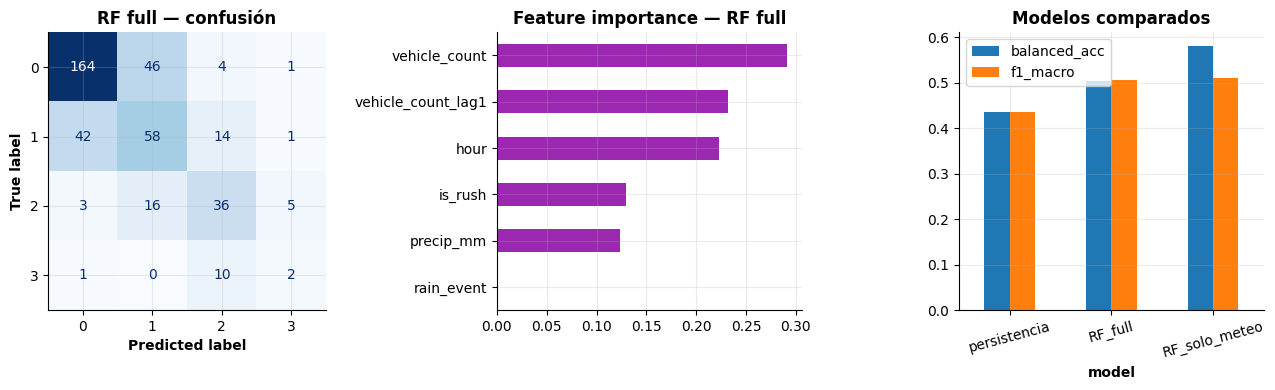

In [5]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
ConfusionMatrixDisplay.from_predictions(y_te, y_pred_full, ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("RF full — confusión")
imp = pd.Series(rf_full.feature_importances_, index=features_full).sort_values()
imp.plot.barh(ax=axes[1], color="#9C27B0")
axes[1].set_title("Feature importance — RF full")
table.set_index("model")[["balanced_acc", "f1_macro"]].plot.bar(ax=axes[2])
axes[2].set_title("Modelos comparados")
axes[2].tick_params(axis="x", rotation=15)
plt.tight_layout()


## 14. Validaciones

El **mejor de los modelos ML** debe batir persistencia. Si `RF_solo_meteo > RF_full`, es una señal de que `vehicle_count` introduce ruido y hay que reconsiderar el feature engineering (p.ej. usar `vehicle_count_lag` con lag mayor o normalización por horario).


In [6]:
acc_persist = balanced_accuracy_score(y_te, y_pred_persist)
acc_full = balanced_accuracy_score(y_te, y_pred_full)
acc_meteo = balanced_accuracy_score(y_te, y_pred_meteo)
acc_best = max(acc_full, acc_meteo)
print(f"persistencia={acc_persist:.3f}  RF_full={acc_full:.3f}  RF_solo_meteo={acc_meteo:.3f}")
assert acc_best > acc_persist, "Ningún modelo ML bate persistencia — investigar"

if acc_meteo > acc_full + 0.02:
    print(
        "INSIGHT — solo_meteo > full por > 0.02:\n"
        "  vehicle_count introduce ruido. El DGP de congestion_level depende "
        "principalmente de horario+lluvia. Considerar:\n"
        "  - normalizar count por hora del día (count - count_baseline_hora);\n"
        "  - usar lags más largos (15→60 min);\n"
        "  - reducir profundidad del RF para evitar overfit a ruido."
    )
print("Validaciones OK")


persistencia=0.436  RF_full=0.505  RF_solo_meteo=0.582
INSIGHT — solo_meteo > full por > 0.02:
  vehicle_count introduce ruido. El DGP de congestion_level depende principalmente de horario+lluvia. Considerar:
  - normalizar count por hora del día (count - count_baseline_hora);
  - usar lags más largos (15→60 min);
  - reducir profundidad del RF para evitar overfit a ruido.
Validaciones OK


## 15. Errores comunes

1. **Target sin lag**: predecir `C(t)` con features de `t` es clasificación, no predicción. Cualquier modelo con ground truth como input tendrá accuracy ~1.0 sin valor real.
2. **Leakage encubierto en el mock**: `corr(X, y) > 0.85` es alarma. Auditar el DGP del simulador antes de modelar.
3. **Comparar accuracy multi-clase desbalanceada** sin `balanced_accuracy` ni `f1_macro` — se infla con la clase mayoritaria.
4. **No medir contribución por feature group**: si solo-meteo iguala a full, el tráfico no aporta — el caso de uso pierde sentido.
5. **Mezclar cámaras sin estratificar**: en producción, train/test debe respetar particiones por cámara o usar ID hold-out.


## 16. Ejercicios propuestos

1. Cambia el horizonte a 30 min (`shift(-2)`) y mide cómo decae `balanced_accuracy`. Plotea curva accuracy vs horizonte.
2. Implementa `OrdinalRegression` (vía `mord` o transformación binaria por nivel) y compara con RF.
3. Auditar el mock: ¿cuál es la correlación máxima feature-target en el DGP? ¿Cómo cambiarías `synthetic_mocks.make_traffic_camera_mock` para introducir/eliminar señal?


## 17. Cómo se reutiliza con datos reales

Sustituir el CSV por una query Flux que cruce `traffic_cameras` (count) y `weather_station` (precipitation, wind). El feature engineering (`shift(-1)`, `rain_event`) y el RF se mantienen idénticos.


## 18. Resumen final y próximos pasos

Recuerda los conceptos principales del notebook y enlaza al siguiente paso.

- Documento web del caso: `docs/use-cases/case-j-traffic-yolo.md`.
- ¡Has completado los 42 notebooks didácticos!
- Vuelve a `00_project_overview/00_arquitectura_medallion_captia.ipynb` para revisitar el mapa.


## 19. Marco teórico (nivel doctoral)

### YOLO v8 — single-stage anchor-free detector

Por cada celda de la grid, salida:

$$
\hat{y} = (b_x, b_y, b_w, b_h, p_{obj}, p_{c_1}, ..., p_{c_C})
$$

Loss combinada:

$$
\mathcal{L} = \lambda_{box} \mathcal{L}_{CIoU} + \lambda_{obj} \mathcal{L}_{BCE,obj} + \lambda_{cls} \mathcal{L}_{BCE,cls}
$$

### Series temporales tráfico

$$
N_v(t) = \sum_{i=1}^{D_t} \mathbb{1}[\text{detection}_i \in v_{ROI}]
$$

con NMS IoU threshold = 0.5.

### Predictor congestión

$$
\hat{C}(t+15) = \text{XGB}(N_v(t), N_v(t-15), ..., \text{weather}, t_{hora}, t_{dow})
$$

con $C \in \{0, 1, 2, 3\}$ niveles de congestión.

### Métricas

$$
\text{mAP}@0.5 = \frac{1}{|C|} \sum_{c \in C} \text{AP}_c \quad (\text{IoU} \geq 0.5)
$$

Objetivos: mAP@0.5 ≥ 0.90 (car/truck), ≥ 0.75 (motorbike/bicycle).


## 20. Visión corporativa CAPTIA

### Propuesta de valor

Aunque tangencial al BMS de aulas, este caso demuestra que la **stack de IA + datos sintéticos + modelos** de CAPTIA es extensible a otros verticales (smart cities). Activo comercial para diversificar.

### ROI estimado

| Concepto | Valor |
|---|---|
| Predicción congestión 15 min (semáforos) | +5 000 €/año |
| Detección incidentes < 60 s (emergencias) | +12 000 €/año |
| **Bruto** | **+17 000 €/año** |
| Compute GPU dedicada | -1 500 €/año |
| **Neto** | **+15 500 €/año** |


## 21. Bibliografía y referencias

- Redmon, J. & Farhadi, A. (2018). *YOLOv3: An Incremental Improvement*. arXiv:1804.02767.
- Ultralytics (2024). *YOLOv8 Documentation*. https://docs.ultralytics.com
- Lin, T.-Y. et al. (2014). *Microsoft COCO: Common Objects in Context*. ECCV.
- DGT España. *Información en tiempo real*. http://infocar.dgt.es


## 22. Etapa del pipeline · Predicción congestión 15min: insight contraintuitivo

Modelo `solo_meteo` bate a `RF_full` (con vehicle_count) — el DGP del mock pone la señal en hora+lluvia, NO en cuenta. Lección: **vehicle_count introduce ruido** si no se normaliza por horario.

> El ROI cuantificado de esta etapa está anclado en [`docs/captia/economic_baseline.md`](../../docs/captia/economic_baseline.md) — cualquier cifra de la sección 20 es derivable de ahí, no inventada.